# Pycistopic

In [1]:
import sys
import scipy as sc
import pandas as pd
sys.path
tmpDir = '/home/bt392/ry/'

In [2]:
import warnings
warnings.simplefilter(action='ignore')
import pycisTopic
pycisTopic.__version__

'1.0.2.dev7+gda26088'

In [3]:
# Project directory
projDir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/SCENICplus/'
# Output directory
outDir = projDir + 'pycistopic/'
import os
if not os.path.exists(outDir):
    os.makedirs(outDir)
work_dir = outDir

### Load in ATAC matrix

In [4]:
# counts matrix needs to be transformed
count_matrix = sc.io.mmread(projDir + 'atac.mtx')
count_matrix_pd = pd.DataFrame(count_matrix.toarray())

In [5]:
cluster_metadata = pd.read_csv(projDir + 'meta_scenic.txt')
peaks = pd.read_csv(projDir + 'peaks.txt')

In [6]:
count_matrix_pd = pd.DataFrame(count_matrix.toarray())

In [7]:
count_matrix_pd.index =  peaks['x'].tolist()
count_matrix_pd.columns = cluster_metadata['cell'].tolist()

In [8]:
count_matrix_pd = count_matrix_pd.T # Unclear to me if this has to be done or not currently
count_matrix_pd.columns = count_matrix_pd.columns.astype(str)

## 1. Creating a cisTopic object

In [ ]:
# Create cisTopic object
from pycisTopic.cistopic_class import *

In [15]:
count_matrix_pd.head()

,chr1:3003470-3004070,chr1:3035598-3036198,chr1:3062639-3063239,chr1:3191587-3192187,chr1:3263590-3264190,chr1:3482948-3483548,chr1:3549212-3549812,chr1:3648855-3649455,chr1:3670533-3671133,chr1:3671493-3672093,...,chrX:169879265-169879865,chrX:169880128-169880728,chrX:169880747-169881347,chrX:169883759-169884359,chrX:169899135-169899735,chrX:169906097-169906697,chrX:169915591-169916191,chrX:169923259-169923859,chrX:169925416-169926016,chrX:169937236-169937836
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,2,0,0,0,0,0,2,0,4,4,...,1,0,0,0,0,0,0,0,0,0
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,0,0,0,2,0,0,0,0,2,4,...,2,0,0,0,0,0,0,0,0,0
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,0,0,0,2,0,0,0,0,0,3,...,4,0,0,0,0,0,0,0,0,0
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,2,0


In [16]:
cistopic_obj = create_cistopic_object(fragment_matrix=count_matrix_pd.T) #, path_to_blacklist=path_to_blacklist)
# Adding cell information
cluster_metadata = cluster_metadata.set_index('cell')
cistopic_obj.add_cell_data(cluster_metadata)

2024-11-26 14:23:02,183 cisTopic     INFO     Converting fragment matrix to sparse matrix
2024-11-26 14:23:36,383 cisTopic     INFO     Creating CistopicObject
2024-11-26 14:23:45,886 cisTopic     INFO     Done!


In [18]:
# Save without doublets
with open(outDir + 'cisTopicObject.pkl', 'wb') as f:
  pickle.dump(cistopic_obj, f)

## 2. Run models

In [19]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [54]:
%%bash
sbatch
#!/bin/bash
#SBATCH -p sapphire #skylake-himem #icelake #skylake #-himem #cclake
#SBATCH -A gottgens-sl2-cpu
### Modify this according to your Ray workload.
#SBATCH --nodes=1
##SBATCH --exclusive # maybe don't specify exclusive 
#SBATCH --tasks-per-node=1
#SBATCH --time 12:00:00
### Modify this according to your Ray workload.
#SBATCH --cpus-per-task=30
#SBATCH --mem-per-cpu=5GB
#SBATCH --gpus-per-task=0
#SBATCH --output logs/jupyter_log-%j.txt


python /rds/project/rds-SDzz0CATGms/users/bt392/software/github/pycisTopic/model_scripts/runModels_lda_mallet.py \
        -i /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/SCENICplus/pycistopic/cisTopicObject.pkl \
        -o /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/SCENICplus/pycistopic/models_500_mallet.pkl \
        -nt 15,20,25 \
        -c 30 \
        -it 500 \
        -a 50 \
        -abt True \
        -e 0.1 \
        -ebt False \
        -sp /home/bt392/ry/ \
        -s 555 \
        -td /home/bt392/ry

Submitted batch job 65187427


## 3. Model selection

In [4]:
# Load cisTopic object
import pickle
infile = open(outDir + 'models_500_mallet.pkl', 'rb')
models = pickle.load(infile)
infile.close()

In [5]:
models

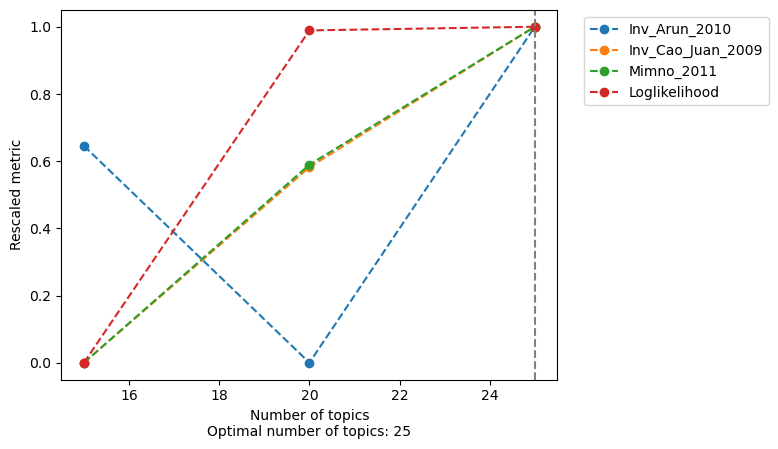

In [6]:
from pycisTopic.lda_models import *
os.mkdir(outDir+'models')
model=evaluate_models(models,
                     select_model=None,
                     return_model=True,
                     metrics=['Arun_2010','Cao_Juan_2009', 'Minmo_2011','loglikelihood'],
                     plot_metrics=False,
                     save= outDir + 'models/model_selection.pdf')

In [7]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [8]:
cistopic_obj.add_LDA_model(model)
pickle.dump(cistopic_obj,
            open(os.path.join(work_dir, 'cisTopicObject.pkl'), 'wb'))

In [9]:
# # Save
# with open(outDir + 'epiblast_blood_cisTopicObject.pkl', 'wb') as f:
#   pickle.dump(cistopic_obj, f)

## 4. Clustering & Visualisation

In [4]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [11]:
from pycisTopic.clust_vis import *
find_clusters(cistopic_obj,
                 target  = 'cell',
                 k = 10,
                 res = [0.6],
                 prefix = 'pycisTopic_',
                 scale = True,
                 split_pattern = '-')

2024-11-27 10:25:01,348 cisTopic     INFO     Finding neighbours


In [12]:
run_umap(cistopic_obj,
                 target  = 'cell', scale=True)

2024-11-27 10:25:03,956 cisTopic     INFO     Running UMAP


In [13]:
cistopic_obj.cell_data.columns

Index(['cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc',
       'cisTopic_log_nr_acc', 'sample_id', 'barcode', 'sample', 'nFeature_RNA',
       'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA',
       'alias', 'day', 'genotype', 'replicate', 'pass_rnaQC', 'doublet_score',
       'doublet_call', 'celltype.mapped_mnn', 'celltype.score_mnn',
       'celltype_extended.mapped_mnn', 'celltype_extended.score_mnn',
       'stage.mapped_mnn', 'cellstage.score_mnn', 'closest.cell_mnn',
       'celltype_genotype', 'celltype_extended_genotype', 'UMAP1', 'UMAP2',
       'mofa_cluster', 'celltype_v1', 'celltype_v2',
       'pycisTopic_leiden_10_0.6'],
      dtype='object')

In [ ]:
os.mkdir(outDir+'/visualization')

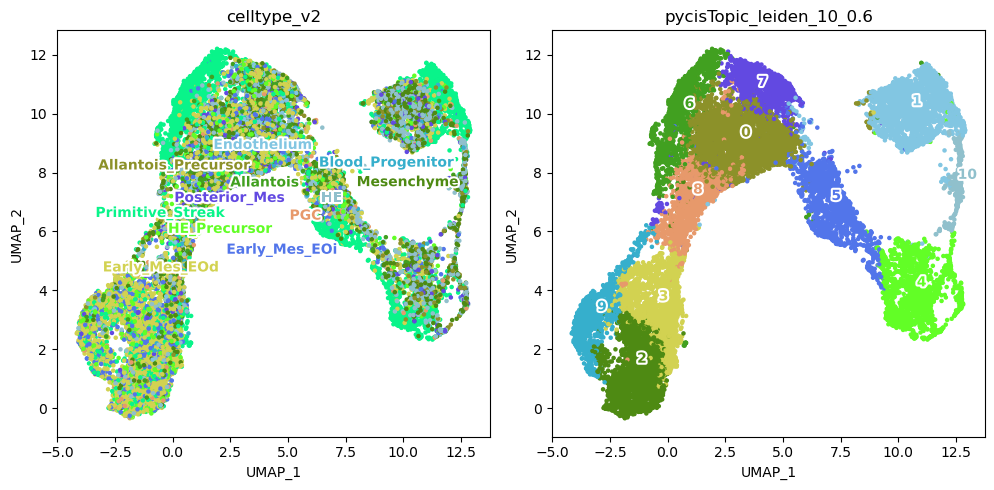

In [16]:
plot_metadata(cistopic_obj,
                 reduction_name='UMAP',
                 variables=['celltype_v2', 'pycisTopic_leiden_10_0.6'], # Labels from RNA and new clusters
                 target='cell', num_columns=3,
                 text_size=10,
                 dot_size=5,
                 figsize=(15,5),
                 save= outDir + 'visualization/dimensionality_reduction_label.pdf')

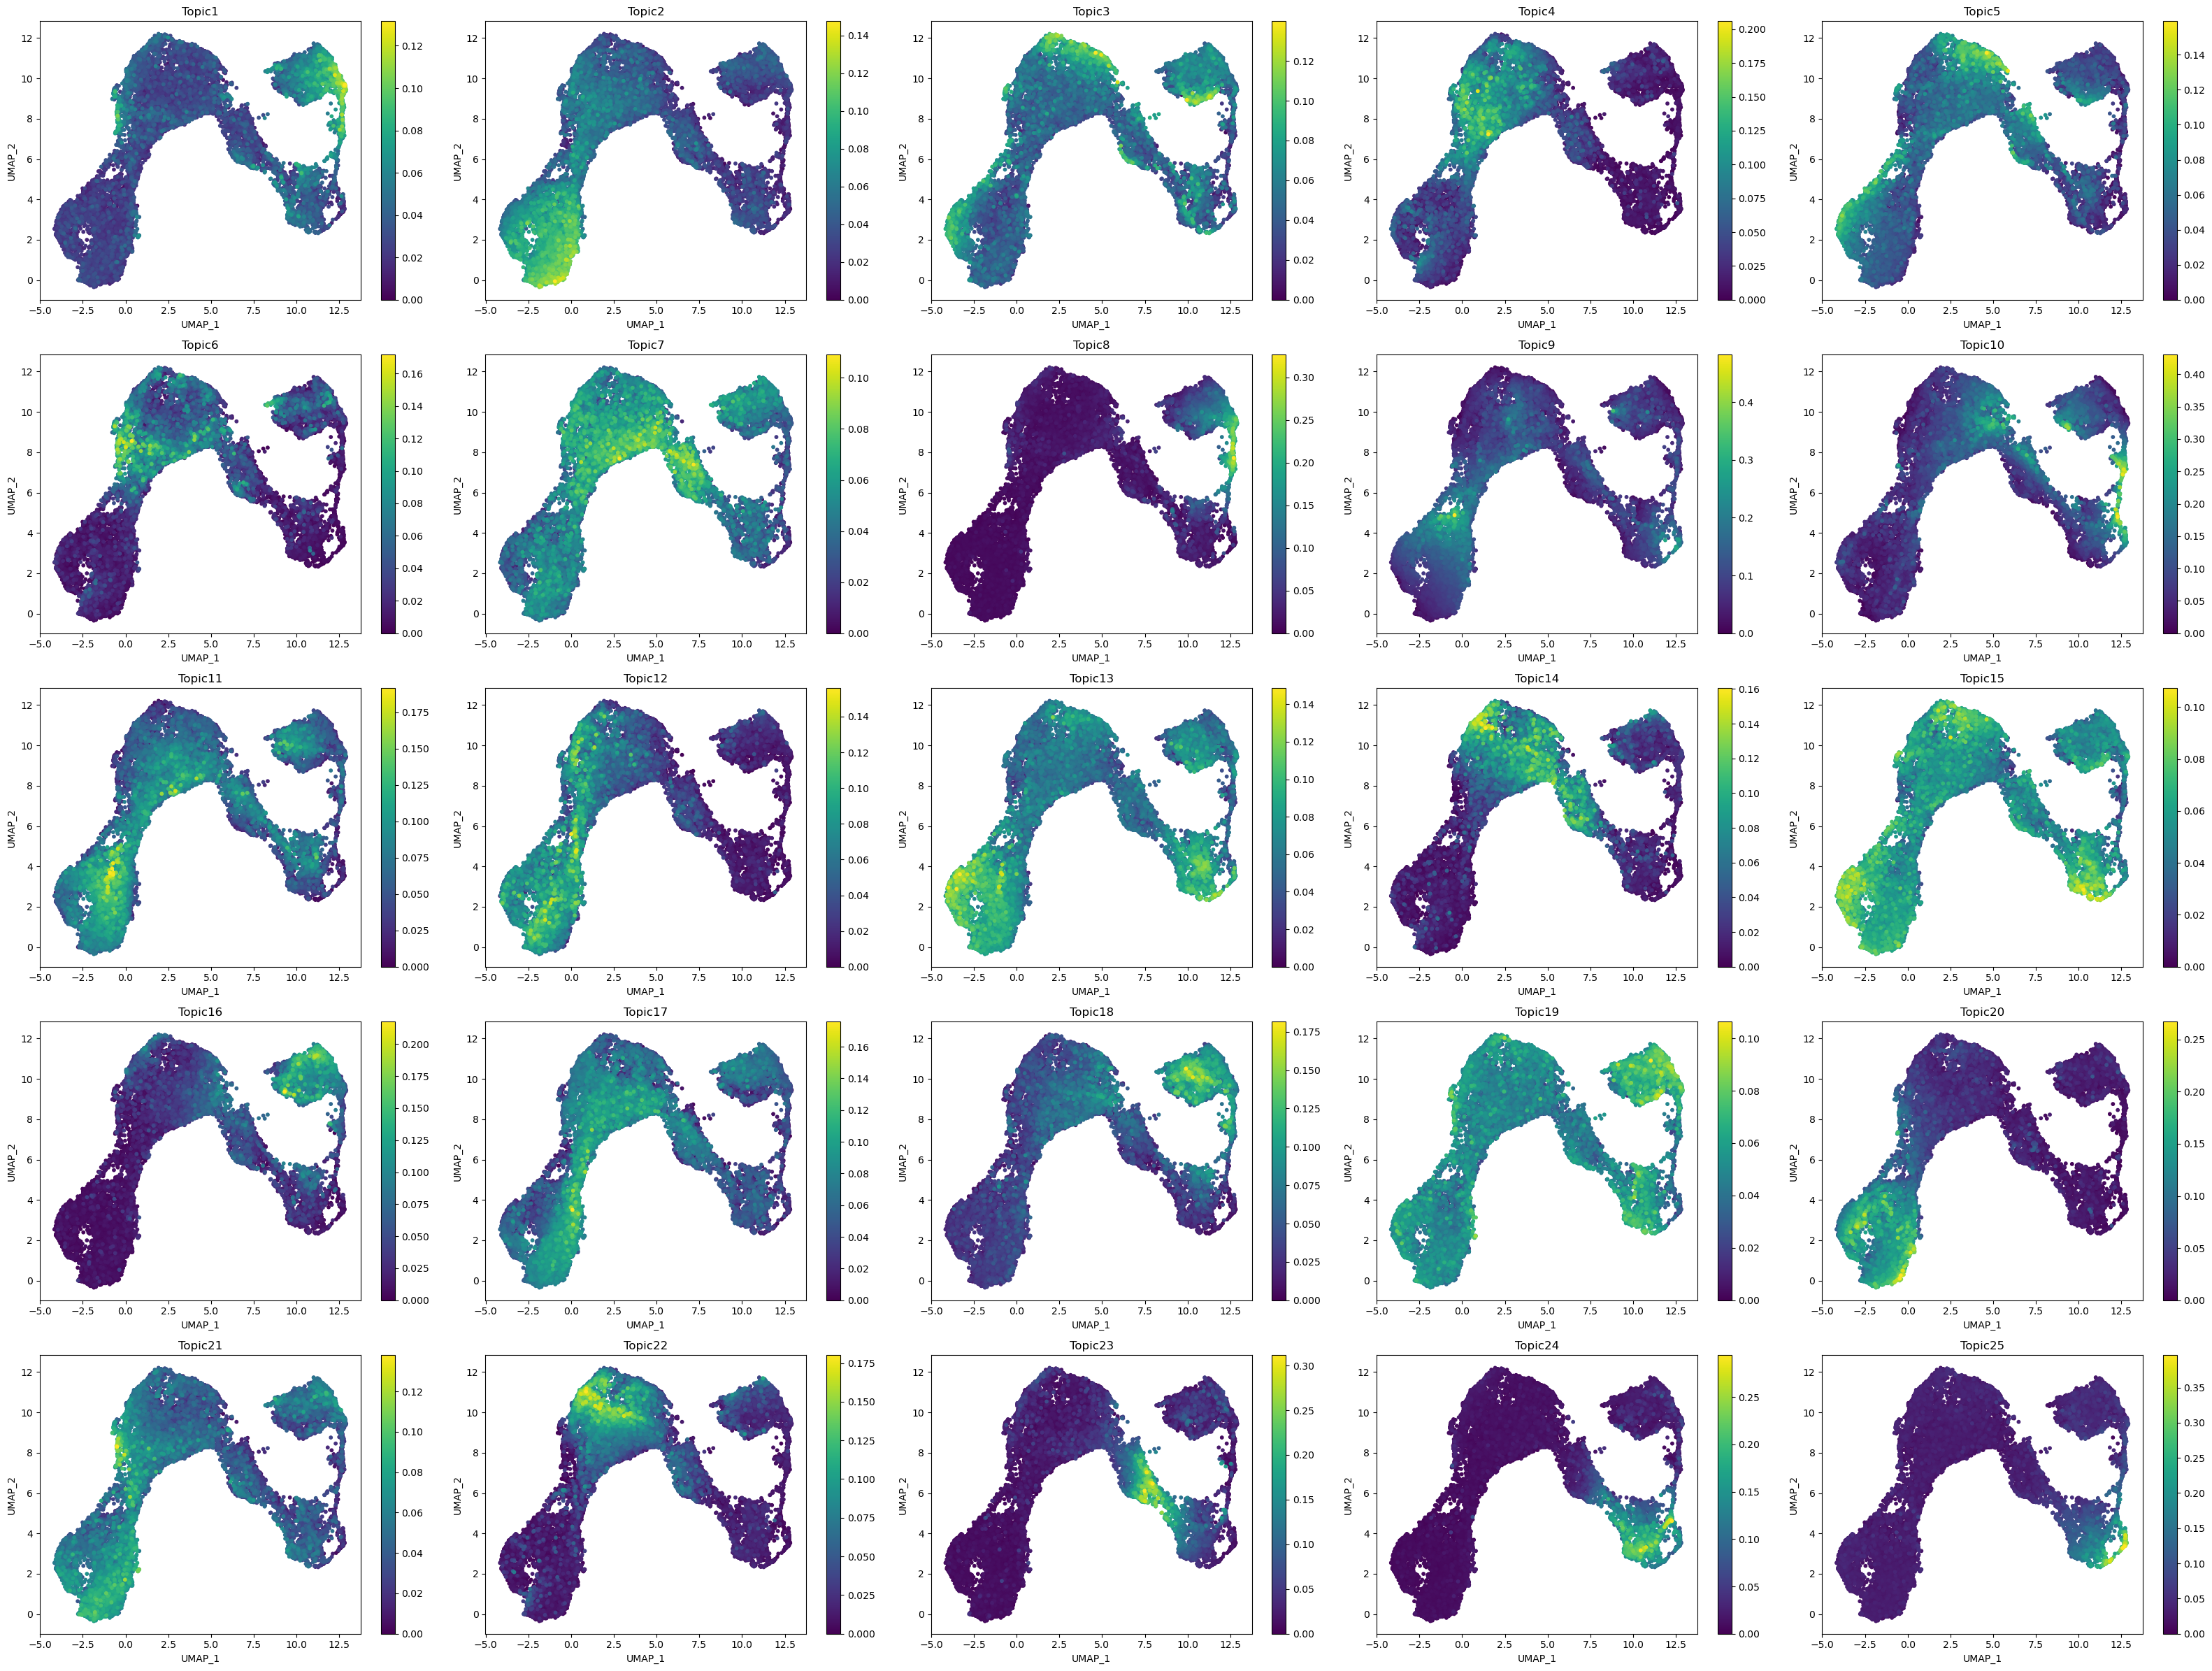

In [17]:
plot_topic(cistopic_obj,
            reduction_name = 'UMAP',
            target = 'cell',
            num_columns=5,
            save= outDir + 'visualization/dimensionality_reduction_topic_contr.pdf')

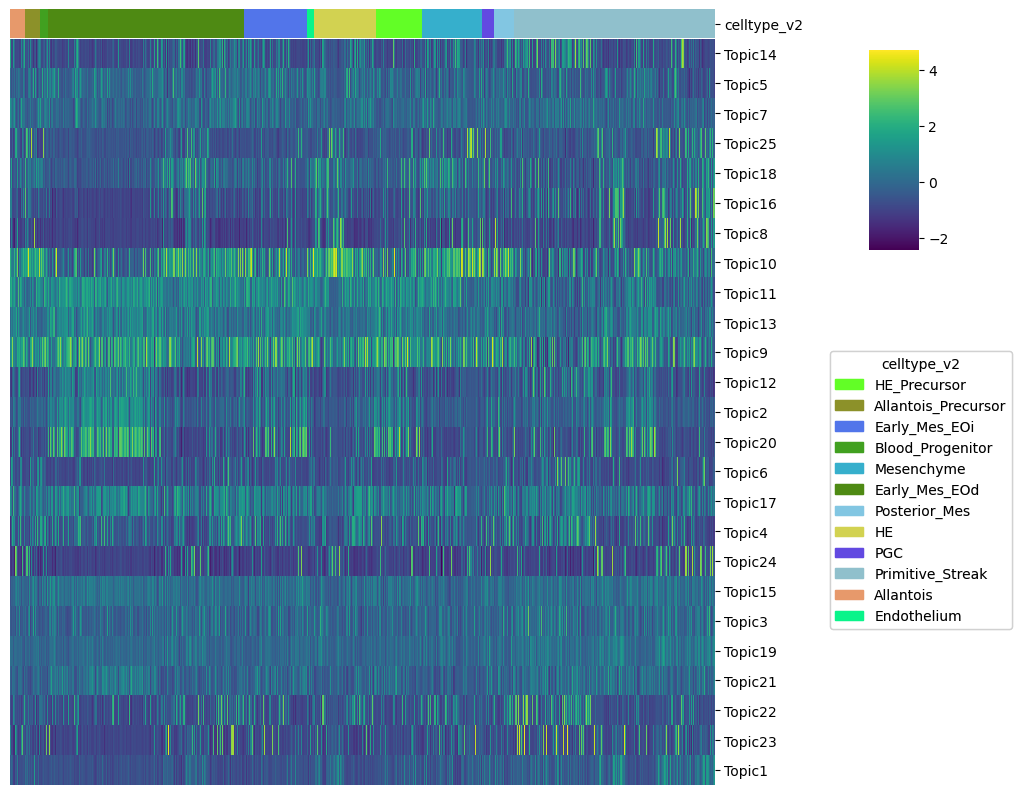

In [18]:
cell_topic_heatmap(cistopic_obj,
                     variables = ['celltype_v2'],
                     scale = True,
                     legend_loc_x = 1.05,
                     legend_loc_y = -1.2,
                     legend_dist_y = -1,
                     figsize=(10,10),
                     save = outDir + 'visualization/heatmap_topic_contr.pdf')

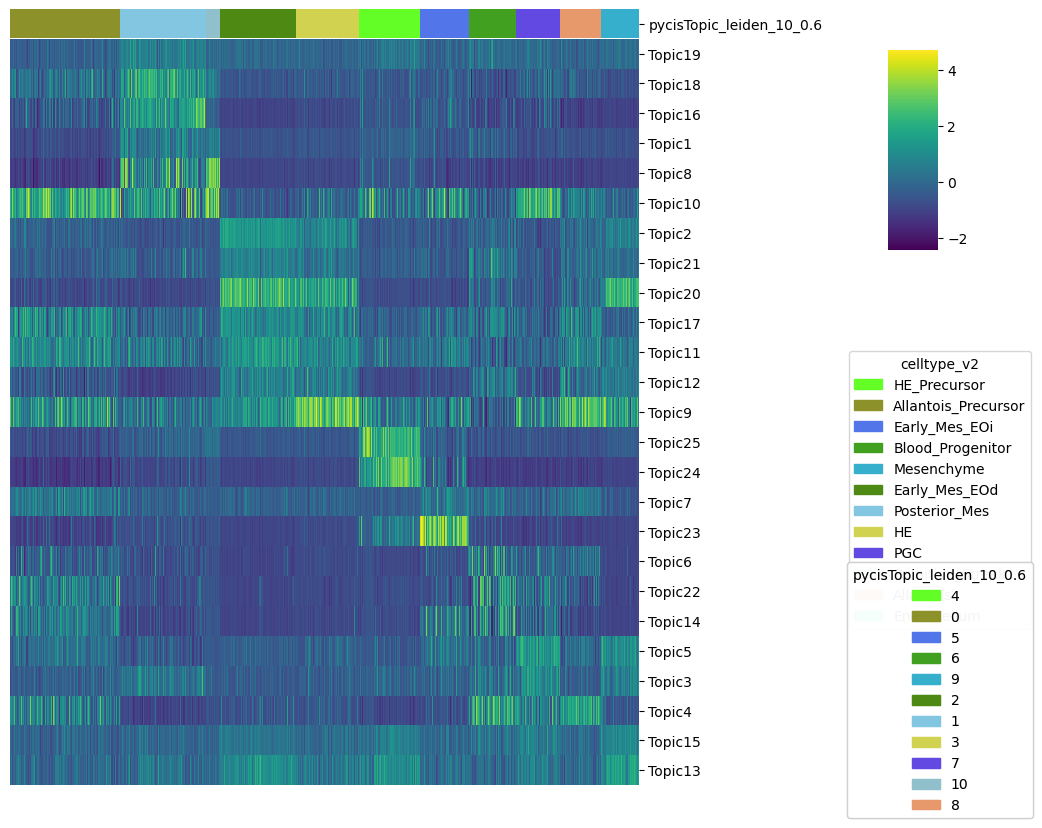

In [19]:
cell_topic_heatmap(cistopic_obj,
                     variables = ['pycisTopic_leiden_10_0.6'],
                     scale = True,
                     legend_loc_x = 1.05,
                     legend_loc_y = -1.2,
                     legend_dist_y = -1,
                     figsize=(10,10),
                     save = outDir + 'visualization/heatmap_topic_contr_clusters.pdf')

In [20]:
# Save
with open(outDir + 'cisTopicObject.pkl', 'wb') as f:
  pickle.dump(cistopic_obj, f)

## 5. Topic binarization & qc

In [21]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

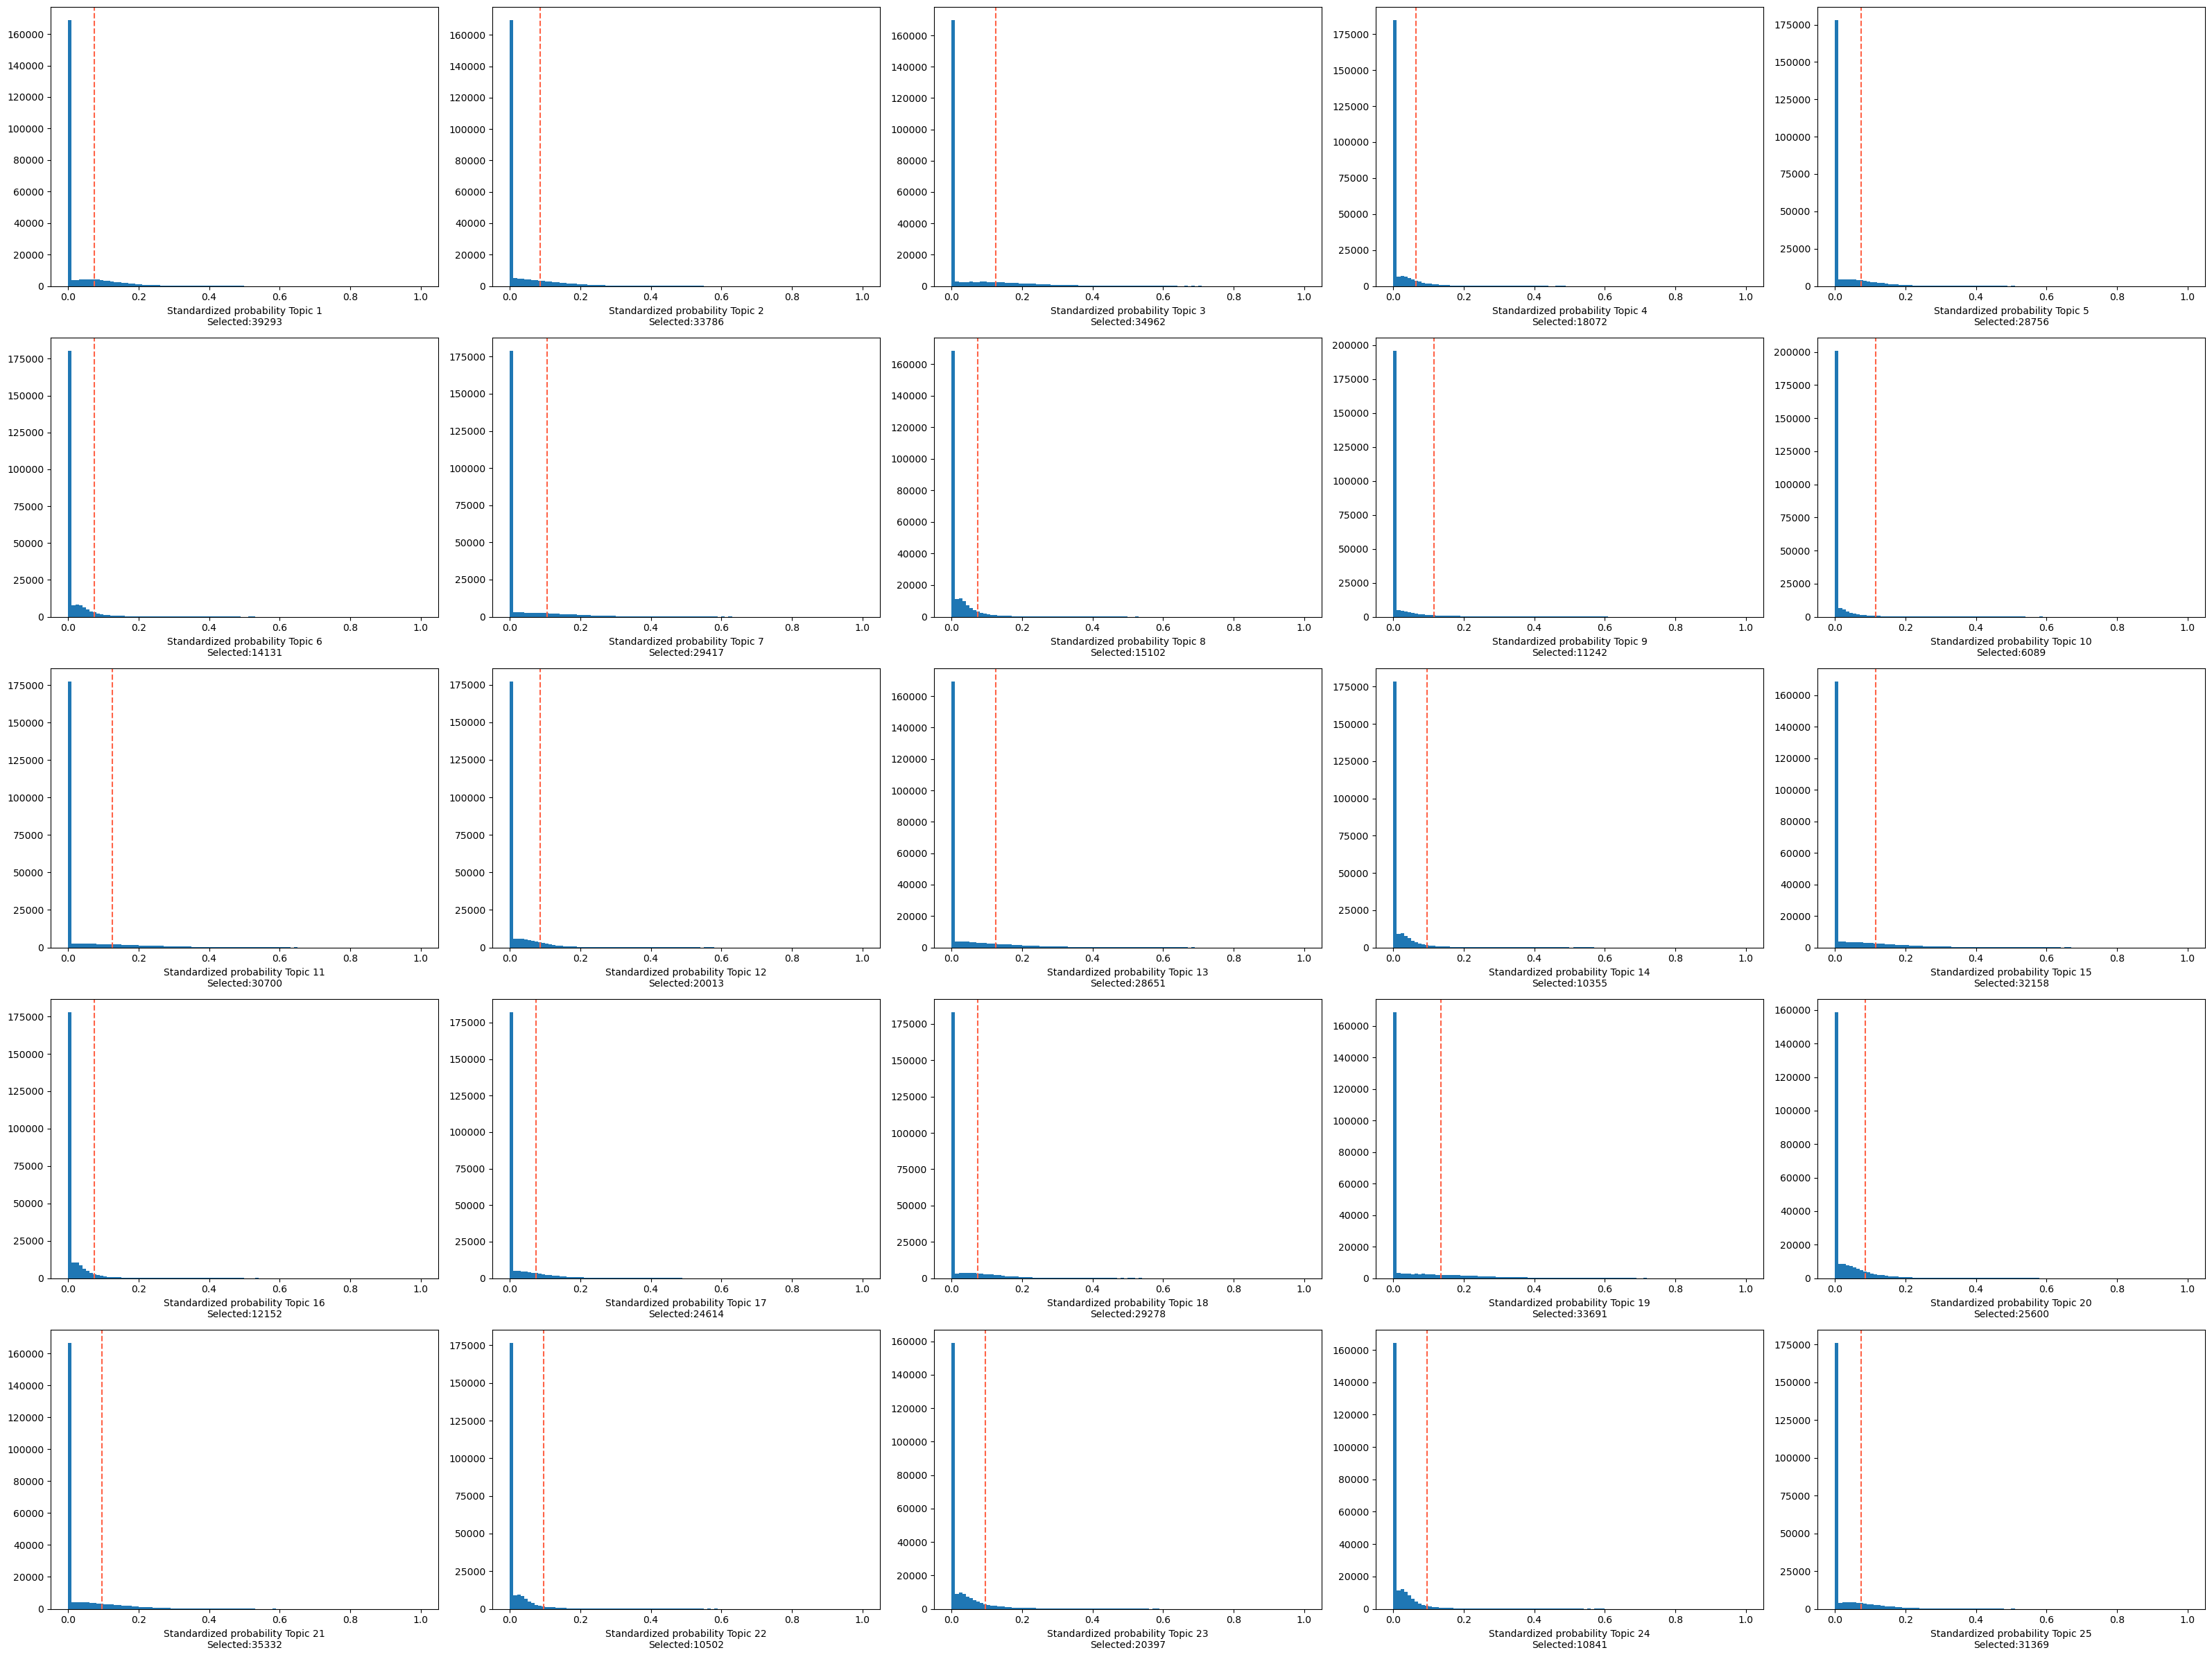

In [22]:
os.mkdir(outDir+'topic_binarization')
from pycisTopic.topic_binarization import *
region_bin_topics = binarize_topics(cistopic_obj, method='otsu', ntop=3000, plot=True, num_columns=5, save= outDir + 'topic_binarization/otsu.pdf')

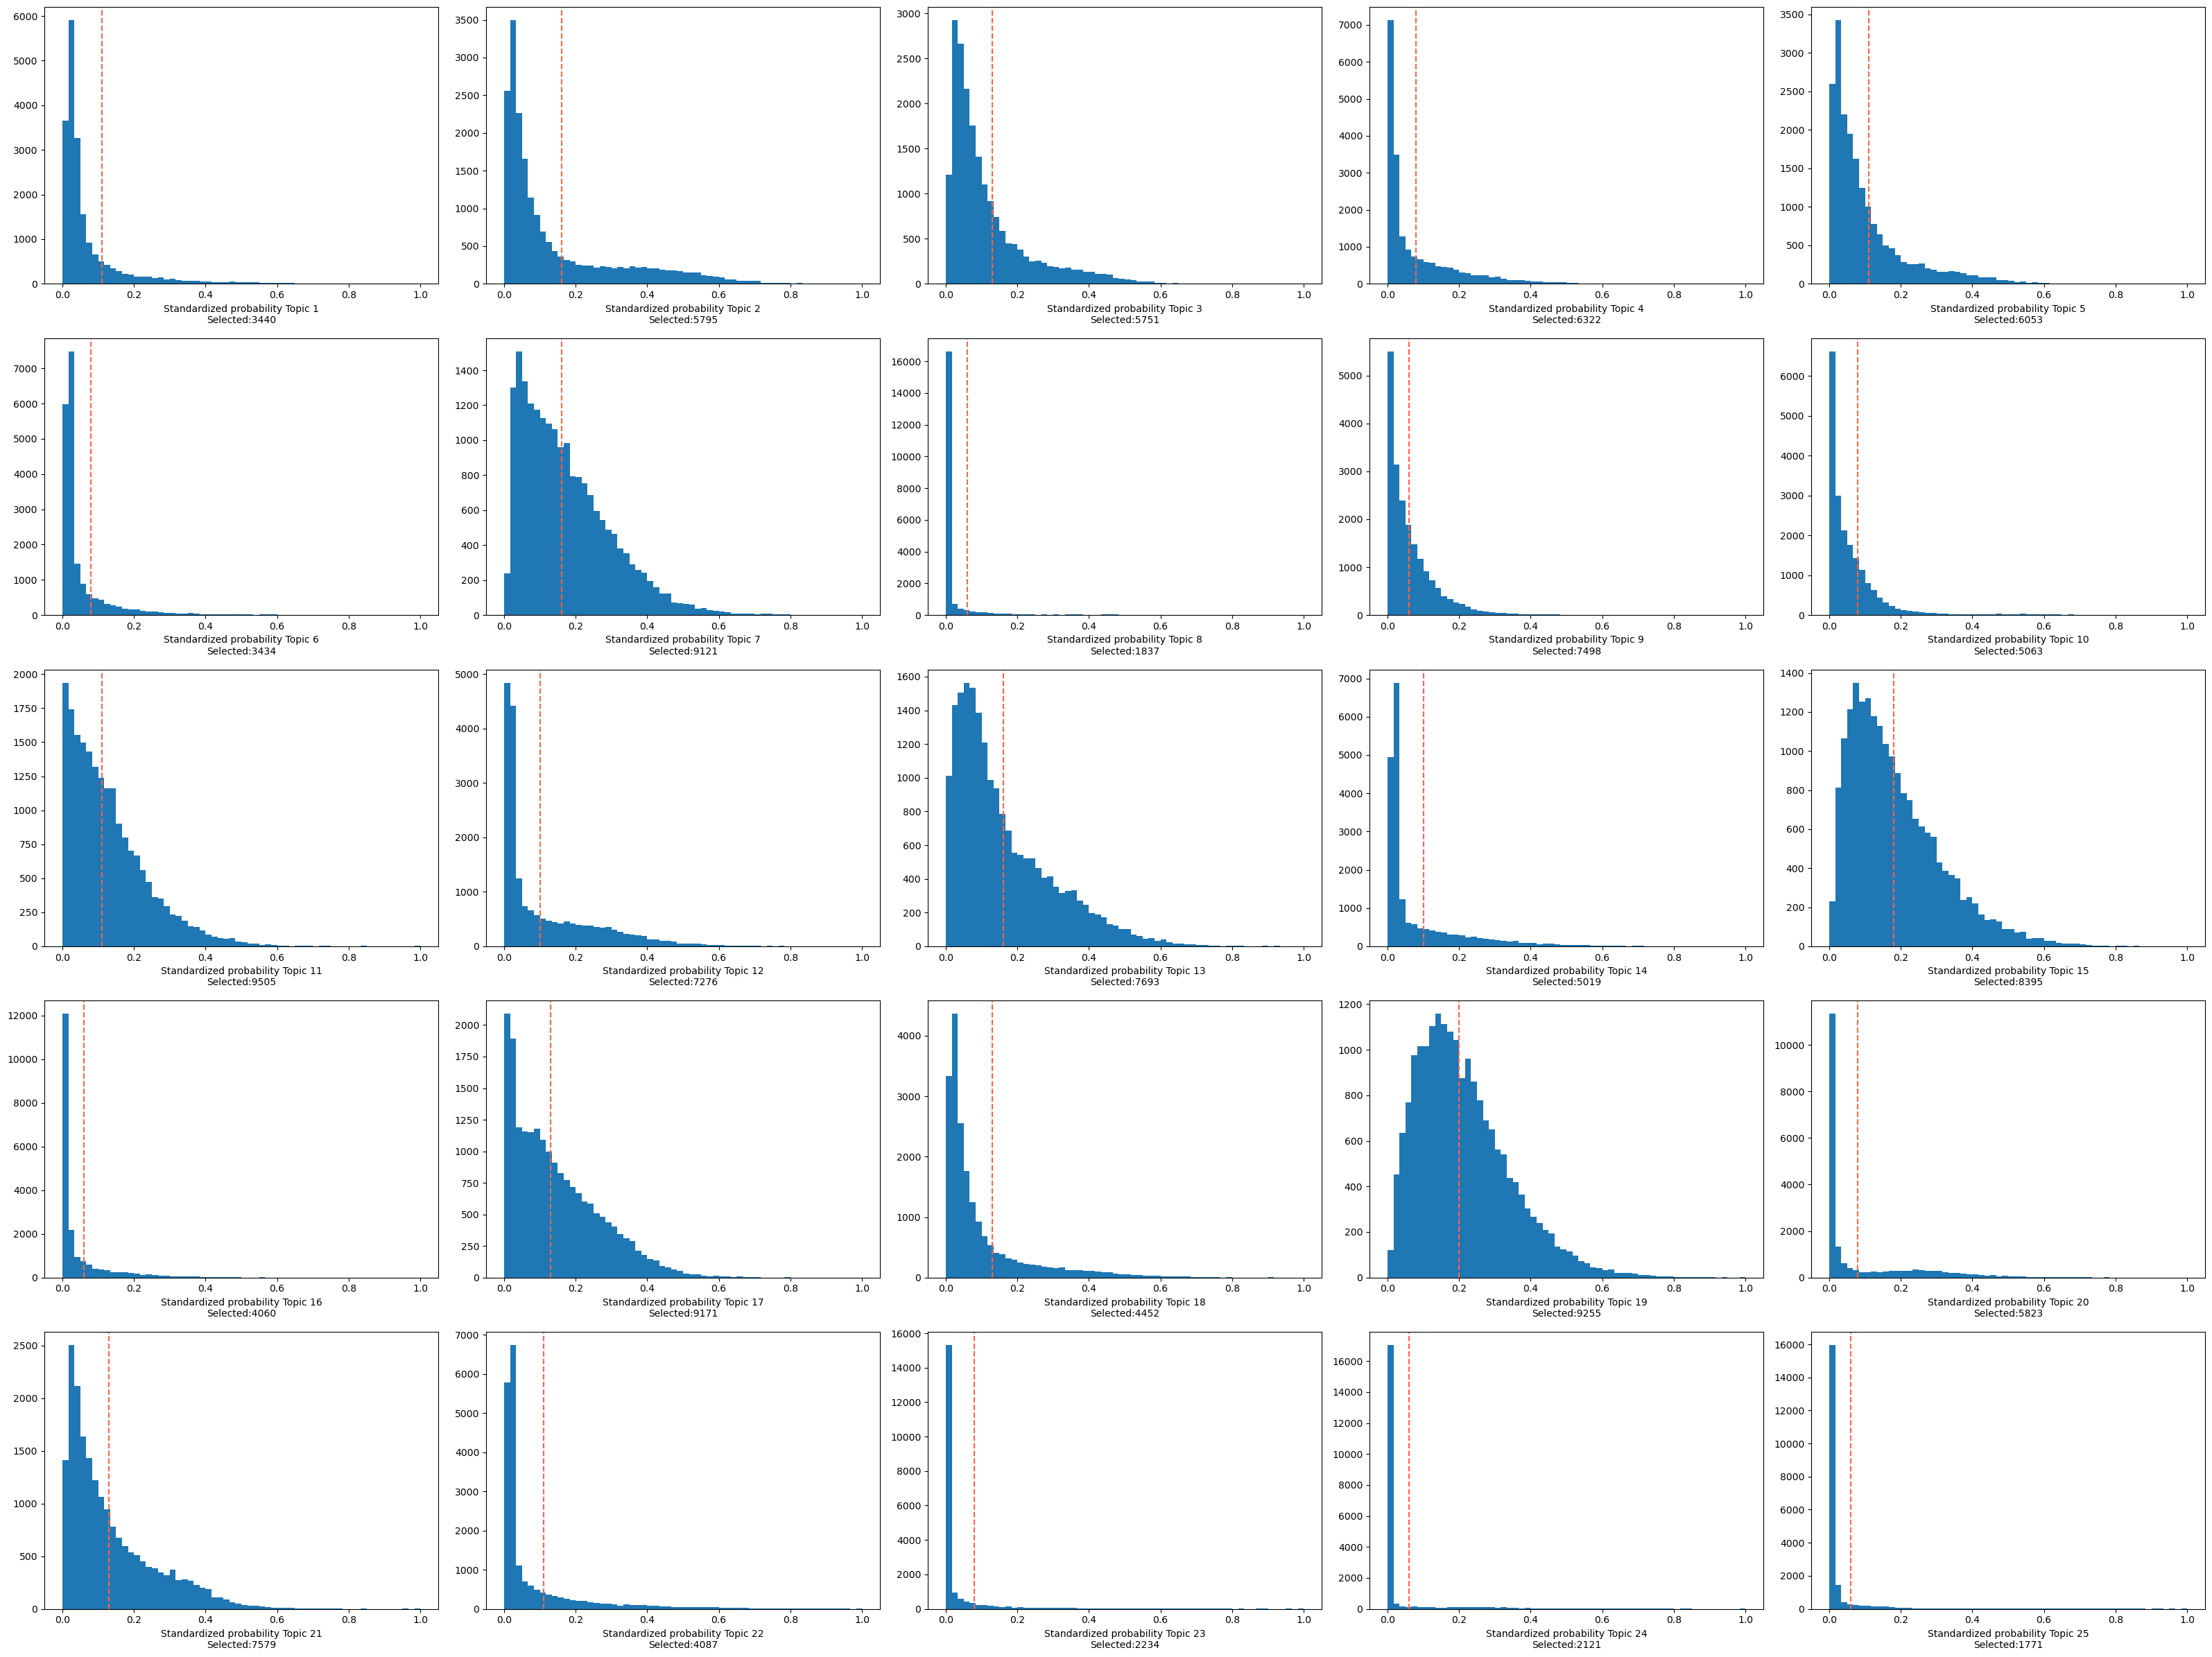

In [23]:
binarized_cell_topic = binarize_topics(cistopic_obj, target='cell', method='li', plot=True, num_columns=5, nbins=60)

In [24]:
from pycisTopic.topic_qc import *
topic_qc_metrics = compute_topic_metrics(cistopic_obj)

In [25]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['AssignmentsVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

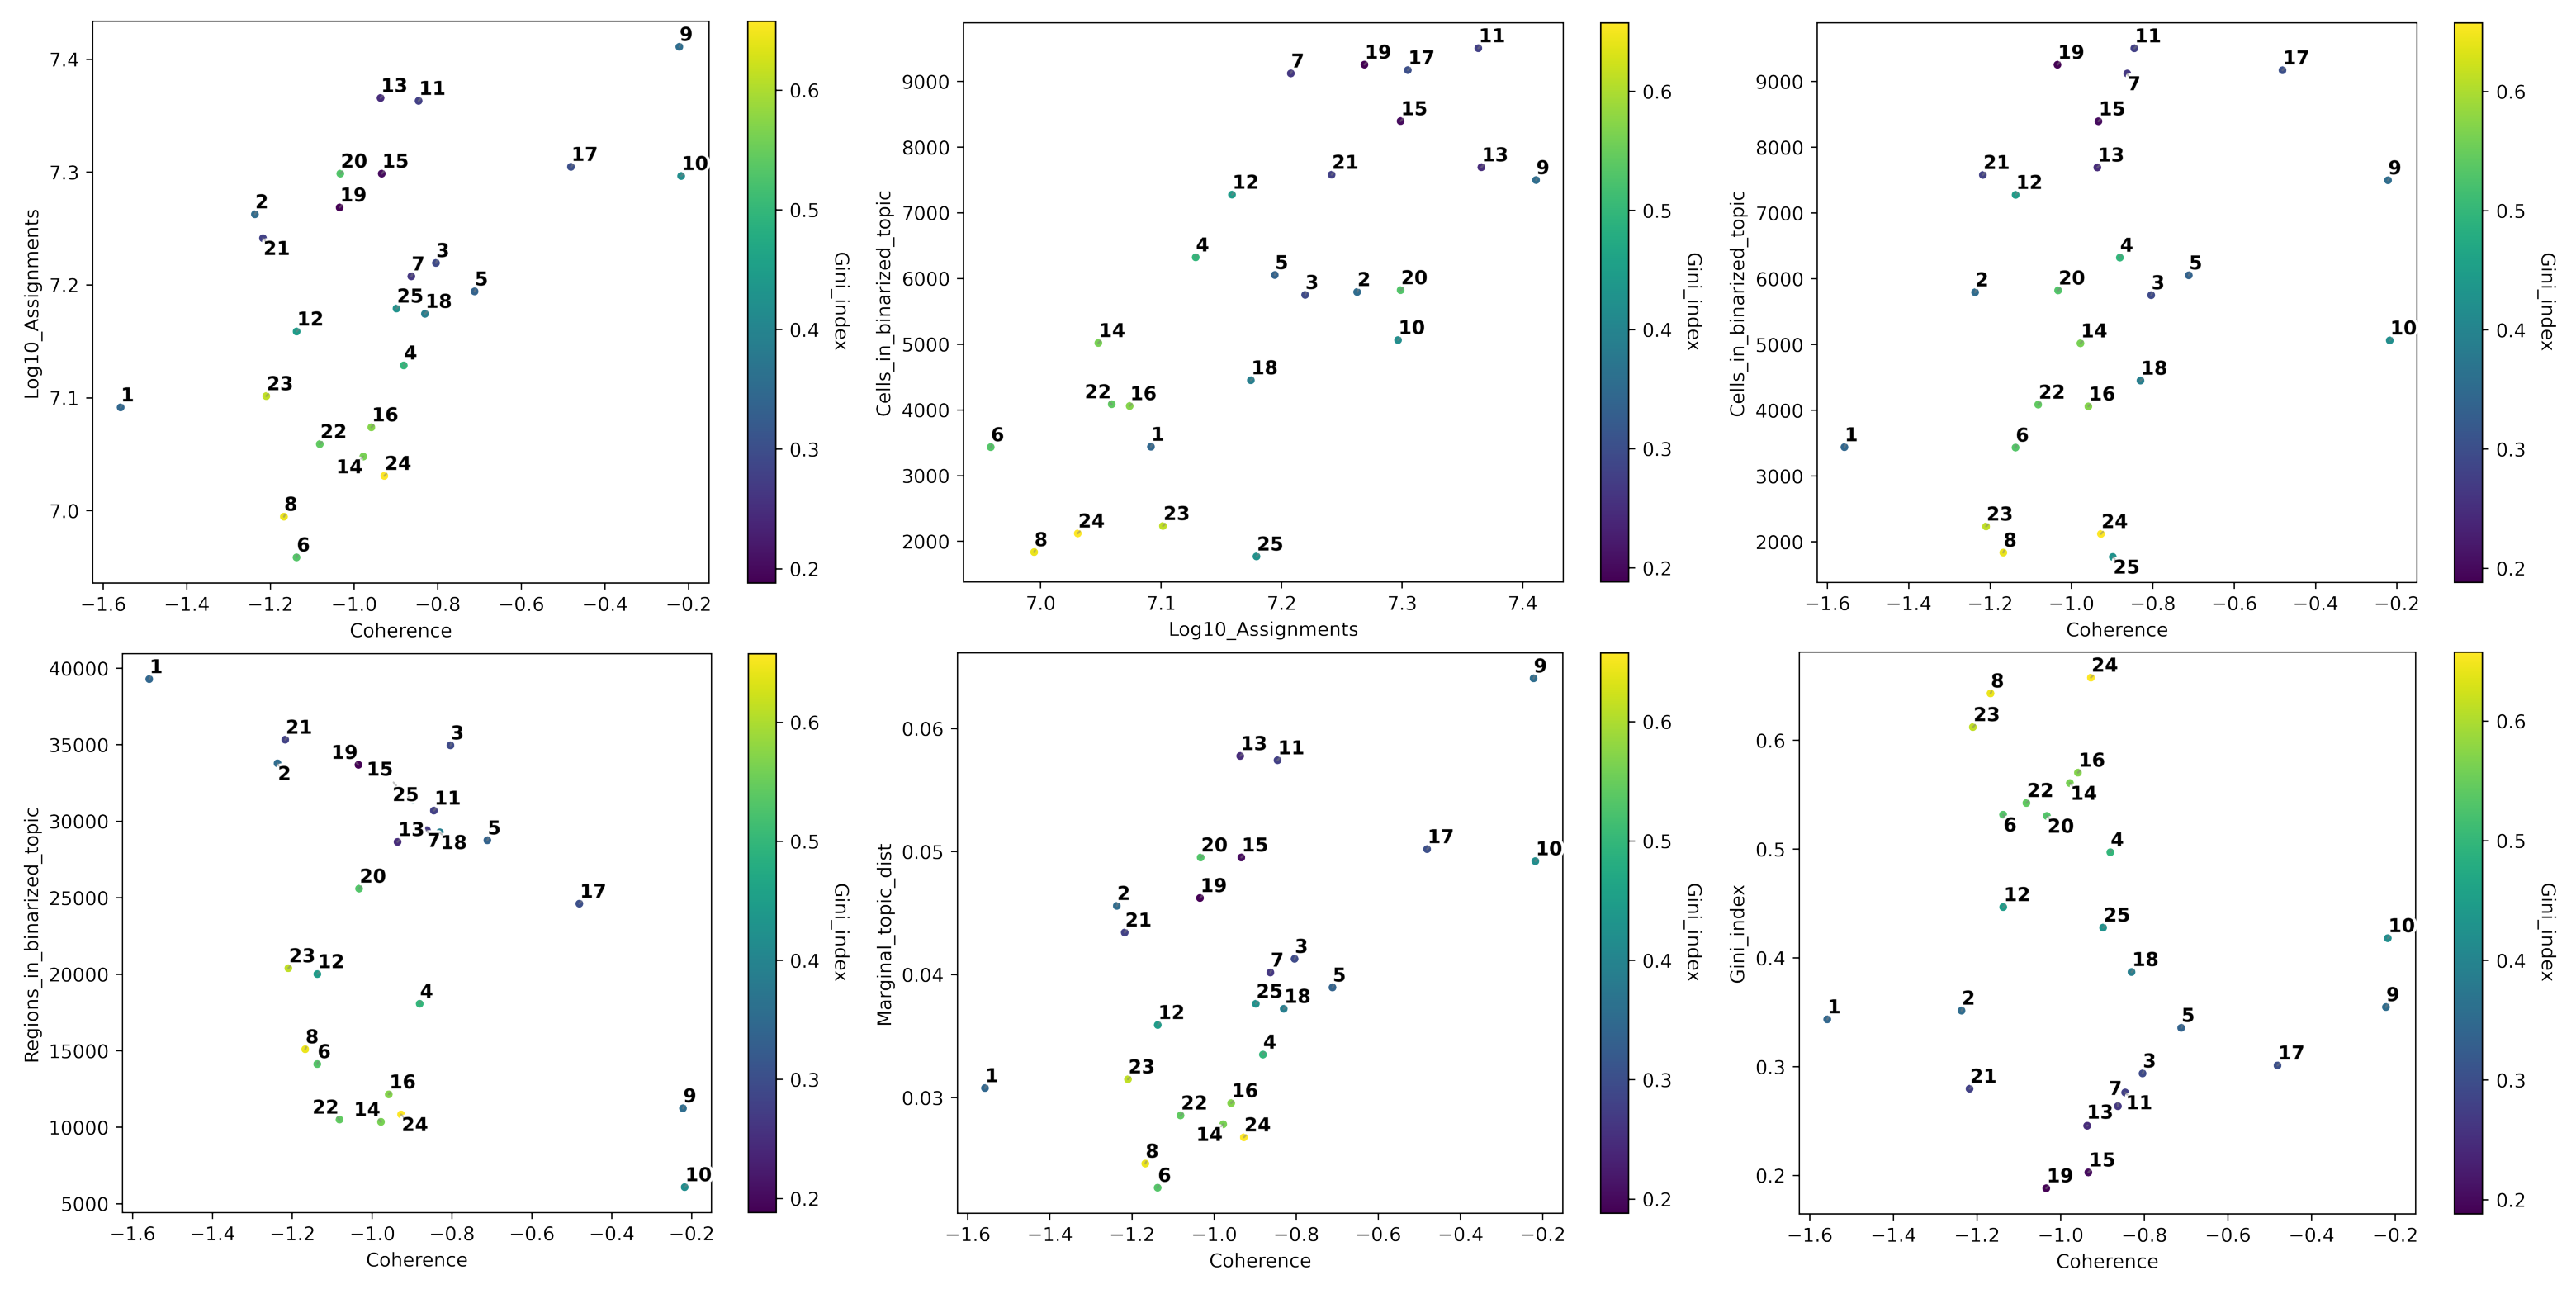

In [26]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
fig.savefig(outDir + 'topic_binarization/Topic_qc.pdf', bbox_inches='tight')
plt.show()

In [27]:
topic_annot = topic_annotation(cistopic_obj, annot_var='celltype_v2', binarized_cell_topic=binarized_cell_topic, general_topic_thr = 0.2)

In [28]:
topic_annot

,celltype_v2,Ratio_cells_in_topic,Ratio_group_in_population,is_general
Topic1,"Allantois_Precursor, Mesenchyme, HE, Primitive...",0.174265,0.477052,False
Topic2,"HE_Precursor, Early_Mes_EOi, Early_Mes_EOd",0.293566,0.432118,False
Topic3,Primitive_Streak,0.291337,0.284144,False
Topic4,"Blood_Progenitor, Mesenchyme, Posterior_Mes, H...",0.320263,0.263526,False
Topic5,"HE_Precursor, Early_Mes_EOi, Early_Mes_EOd, PG...",0.306636,0.471581,False
Topic6,"Blood_Progenitor, Posterior_Mes, Primitive_Str...",0.173961,0.357244,False
Topic7,"Blood_Progenitor, Mesenchyme, Early_Mes_EOd, P...",0.462057,0.453647,False
Topic8,"Allantois_Precursor, Mesenchyme, HE, Primitive...",0.09306,0.477052,False
Topic9,"HE_Precursor, Early_Mes_EOi, Early_Mes_EOd, PGC",0.379838,0.449848,False
Topic10,"Allantois_Precursor, Blood_Progenitor, Mesench...",0.256484,0.266008,False


In [29]:
topic_qc_metrics = pd.concat([topic_annot[['celltype_v2', 'Ratio_cells_in_topic', 'Ratio_group_in_population']], topic_qc_metrics], axis=1)

In [30]:
topic_qc_metrics

,celltype_v2,Ratio_cells_in_topic,Ratio_group_in_population,Log10_Assignments,Assignments,Regions_in_binarized_topic,Cells_in_binarized_topic,Coherence,Marginal_topic_dist,Gini_index
Topic1,"Allantois_Precursor, Mesenchyme, HE, Primitive...",0.174265,0.477052,7.091576,12347422.0,39293,3440,-1.558110,0.030782,0.343536
Topic2,"HE_Precursor, Early_Mes_EOi, Early_Mes_EOd",0.293566,0.432118,7.262650,18308385.0,33786,5795,-1.236993,0.045588,0.351547
Topic3,Primitive_Streak,0.291337,0.284144,7.219514,16577296.0,34962,5751,-0.804103,0.041285,0.293829
Topic4,"Blood_Progenitor, Mesenchyme, Posterior_Mes, H...",0.320263,0.263526,7.128714,13449745.0,18072,6322,-0.881124,0.033503,0.497147
Topic5,"HE_Precursor, Early_Mes_EOi, Early_Mes_EOd, PG...",0.306636,0.471581,7.194307,15642534.0,28756,6053,-0.711719,0.038957,0.335719
Topic6,"Blood_Progenitor, Posterior_Mes, Primitive_Str...",0.173961,0.357244,6.958640,9091585.0,14131,3434,-1.137552,0.022684,0.531659
Topic7,"Blood_Progenitor, Mesenchyme, Early_Mes_EOd, P...",0.462057,0.453647,7.207644,16130346.0,29417,9121,-0.863023,0.040174,0.263738
Topic8,"Allantois_Precursor, Mesenchyme, HE, Primitive...",0.09306,0.477052,6.994681,9878278.0,15102,1837,-1.167641,0.024644,0.643118
Topic9,"HE_Precursor, Early_Mes_EOi, Early_Mes_EOd, PGC",0.379838,0.449848,7.411076,25767748.0,11242,7498,-0.222050,0.064077,0.354804
Topic10,"Allantois_Precursor, Blood_Progenitor, Mesench...",0.256484,0.266008,7.296568,19795566.0,6089,5063,-0.217732,0.049224,0.418147


In [31]:
# Save
with open(outDir + 'topic_binarization/Topic_qc_metrics_annot.pkl', 'wb') as f:
  pickle.dump(topic_qc_metrics, f)
with open(outDir + 'topic_binarization/binarized_cell_topic.pkl', 'wb') as f:
  pickle.dump(binarized_cell_topic, f)
with open(outDir + 'topic_binarization/binarized_topic_region.pkl', 'wb') as f:
  pickle.dump(region_bin_topics, f)

## 6. Differentially Accessible Regions (DARs)

In [15]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [16]:
from pycisTopic.diff_features import *
imputed_acc_obj = impute_accessibility(cistopic_obj, selected_cells=None, selected_regions=None, scale_factor=10**6)

2024-11-27 11:42:56,017 cisTopic     INFO     Imputing drop-outs
2024-11-27 11:46:12,101 cisTopic     INFO     Scaling
2024-11-27 11:46:23,191 cisTopic     INFO     Keep non zero rows
2024-11-27 11:47:13,290 cisTopic     INFO     Imputed accessibility sparsity: 0.22606955432207365
2024-11-27 11:47:13,302 cisTopic     INFO     Create CistopicImputedFeatures object
2024-11-27 11:47:13,302 cisTopic     INFO     Done!


In [ ]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

2024-11-27 11:47:13,346 cisTopic     INFO     Normalizing imputed data


In [ ]:
os.mkdir(outDir+'DARs')
variable_regions = find_highly_variable_features(normalized_imputed_acc_obj,
                                           min_disp = 0.05,
                                           min_mean = 0.0125,
                                           max_mean = 3,
                                           max_disp = np.inf,
                                           n_bins=20,
                                           n_top_features=None,
                                           plot=True,
                                           save= outDir + 'DARs/HVR_plot.pdf')

In [ ]:
len(variable_regions)

In [ ]:
ray.shutdown()

In [ ]:
markers_dict= find_diff_features(cistopic_obj,
                      imputed_acc_obj,
                      variable='celltype_v2',
                      var_features=variable_regions,
                      contrasts=None,
                      adjpval_thr=0.05,
                      log2fc_thr=np.log2(0.5),
                      n_cpu=5,
                      _temp_dir=tmpDir,
                      split_pattern = '-')

In [ ]:
markers_dict

In [ ]:
from pycisTopic.clust_vis import *
plot_imputed_features(cistopic_obj,
                    reduction_name='UMAP',
                    imputed_data=imputed_acc_obj,
                    features=[markers_dict[x].index.tolist()[0] for x in ['Early_Mes_EOi', 'Early_Mes_EOd']],
                    scale=False,
                    num_columns=4,
                    save= outDir + 'DARs/example_best_DARs.pdf')

In [ ]:
x = [print(x + ': '+ str(len(markers_dict[x]))) for x in markers_dict.keys()]

In [ ]:
if not os.path.exists(os.path.join(work_dir, 'scATAC/candidate_enhancers')):
    os.makedirs(os.path.join(work_dir, 'scATAC/candidate_enhancers'))
import pickle
pickle.dump(markers_dict, open(os.path.join(work_dir, 'scATAC/candidate_enhancers/markers_dict.pkl'), 'wb'))
pickle.dump(imputed_acc_obj, open(outDir + 'DARs/Imputed_accessibility.pkl', 'wb'))

# Motif enrichment analysis using pycistarget

In [5]:
import sys
import scipy as sc
import pandas as pd
sys.path
tmpDir = '/home/bt392/ry/'

import warnings
warnings.simplefilter(action='ignore')
import pycisTopic
pycisTopic.__version__

import os
if not os.path.exists(outDir):
    os.makedirs(outDir)
work_dir = outDir

In [6]:
import pickle
region_bin_topics_otsu = pickle.load(open(os.path.join(work_dir, 'topic_binarization/binarized_topic_region.pkl'), 'rb'))
#region_bin_topics_top3k = pickle.load(open(os.path.join(work_dir, 'scATAC/candidate_enhancers/region_bin_topics_top3k.pkl'), 'rb'))
markers_dict = pickle.load(open(os.path.join(work_dir, 'scATAC/candidate_enhancers/markers_dict.pkl'), 'rb'))

In [8]:
import pyranges as pr
from pycistarget.utils import region_names_to_coordinates
region_sets = {}
region_sets['topics_otsu'] = {}
# region_sets['topics_top_3'] = {}
region_sets['DARs'] = {}
for topic in region_bin_topics_otsu.keys():
    regions = region_bin_topics_otsu[topic].index[region_bin_topics_otsu[topic].index.str.startswith('chr')] #only keep regions on known chromosomes
    region_sets['topics_otsu'][topic] = pr.PyRanges(region_names_to_coordinates(regions))
# for topic in region_bin_topics_top3k.keys():
#     regions = region_bin_topics_top3k[topic].index[region_bin_topics_top3k[topic].index.str.startswith('chr')] #only keep regions on known chromosomes
#     region_sets['topics_top_3'][topic] = pr.PyRanges(region_names_to_coordinates(regions))
# for DAR in markers_dict.keys():
#     regions = markers_dict[DAR].index[markers_dict[DAR].index.str.startswith('chr')] #only keep regions on known chromosomes
#     region_sets['DARs'][DAR] = pr.PyRanges(region_names_to_coordinates(regions))

In [9]:
for key in region_sets.keys():
    print(f'{key}: {region_sets[key].keys()}')

topics_otsu: dict_keys(['Topic1', 'Topic2', 'Topic3', 'Topic4', 'Topic5', 'Topic6', 'Topic7', 'Topic8', 'Topic9', 'Topic10', 'Topic11', 'Topic12', 'Topic13', 'Topic14', 'Topic15', 'Topic16', 'Topic17', 'Topic18', 'Topic19', 'Topic20', 'Topic21', 'Topic22', 'Topic23', 'Topic24', 'Topic25'])
DARs: dict_keys([])


In [10]:
db_fpath = "/rds/project/rds-SDzz0CATGms/users/bt392/software/cistarget_database/mm10"
motif_annot_fpath = "/rds/project/rds-SDzz0CATGms/users/bt392/software/cistarget_database/mm10"

In [11]:
rankings_db = os.path.join(db_fpath, 'mm10_screen_v10_clust.regions_vs_motifs.rankings.feather')
scores_db =  os.path.join(db_fpath, 'mm10_screen_v10_clust.regions_vs_motifs.scores.feather')
motif_annotation = os.path.join(motif_annot_fpath, 'motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl')

In [12]:
if not os.path.exists(os.path.join(work_dir, 'motifs')):
    os.makedirs(os.path.join(work_dir, 'motifs'))

In [13]:
from scenicplus.wrappers.run_pycistarget import run_pycistarget
run_pycistarget(
    region_sets = region_sets,
    species = 'mus_musculus',
    save_path = os.path.join(work_dir, 'motifs'),
    ctx_db_path = rankings_db,
    dem_db_path = scores_db,
    path_to_motif_annotations = motif_annotation,
    run_without_promoters = False,
    n_cpu = 5,
    _temp_dir = tmpDir,
    annotation_version = 'v10nr_clust',
    )

2024-11-27 11:16:07,495 pycisTarget_wrapper INFO     /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/SCENICplus/pycistopic/motifs folder already exists.
2024-11-27 11:16:08,300 pycisTarget_wrapper INFO     Loading cisTarget database for topics_otsu
2024-11-27 11:16:08,301 cisTarget    INFO     Reading cisTarget database
2024-11-27 11:17:51,662 pycisTarget_wrapper INFO     Running cisTarget for topics_otsu


2024-11-27 11:17:57,290	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(ctx_internal_ray pid=19477) 2024-11-27 11:18:11,450 cisTarget    INFO     Running cisTarget for Topic2 which has 41029 regions
(ctx_internal_ray pid=19478) 2024-11-27 11:18:11,452 cisTarget    INFO     Running cisTarget for Topic5 which has 36527 regions
(ctx_internal_ray pid=19479) 2024-11-27 11:18:11,450 cisTarget    INFO     Running cisTarget for Topic4 which has 21608 regions
(ctx_internal_ray pid=19475) 2024-11-27 11:18:11,450 cisTarget    INFO     Running cisTarget for Topic3 which has 41052 regions
(ctx_internal_ray pid=19476) 2024-11-27 11:18:11,450 cisTarget    INFO     Running cisTarget for Topic1 which has 44998 regions
2024-11-27 11:20:52,017 cisTarget    INFO     Done!
2024-11-27 11:20:52,037 pycisTarget_wrapper INFO     /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/SCENICplus/pycistopic/motifs/CTX_topics_otsu_All folder already exists.
2024-11-27 11:20:52,272 pycisTarget_wrapper INFO     Running DEM for topics_otsu
2024-1

2024-11-27 11:23:25,022	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(DEM_internal_ray pid=20390) 2024-11-27 11:23:36,530 DEM          INFO     Computing DEM for Topic4
(DEM_internal_ray pid=20389) 2024-11-27 11:23:43,711 DEM          INFO     Computing DEM for Topic2
(DEM_internal_ray pid=20391) 2024-11-27 11:23:44,429 DEM          INFO     Computing DEM for Topic3
(DEM_internal_ray pid=20393) 2024-11-27 11:23:44,909 DEM          INFO     Computing DEM for Topic1
(DEM_internal_ray pid=20392) 2024-11-27 11:23:46,584 DEM          INFO     Computing DEM for Topic5
2024-11-27 11:29:56,337 DEM          INFO     Forming cistromes
2024-11-27 11:30:05,259 DEM          INFO     Done!
2024-11-27 11:30:09,452 pycisTarget_wrapper INFO     Created folder : /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/revisions/05_SCENICplus/SCENICplus/pycistopic/motifs/DEM_topics_otsu_All
2024-11-27 11:30:09,859 pycisTarget_wrapper INFO     Loading cisTarget database for DARs
2024-11-27 11:30:09,859 cisTarget    INFO     Reading cisTarget database


ValueError: A gene signature must have at least one gene.

In [ ]:
import dill
menr = dill.load(open(os.path.join(work_dir, 'motifs/menr.pkl'), 'rb'))